# **Install requirements**

In [0]:
!pip3 install 'torch==1.4.0'
!pip3 install 'torchvision>=0.5.0'
!pip3 install 'Pillow-SIMD'
!pip3 install 'tqdm'

**Import LFWCrop Dataset from GitHub**

In [0]:
import os
!rm -rf lfwcrop
!rm -rf output
!git clone https://github.com/Antonio210696/LFWCrop_dataset_pytorch lfwcrop
os.chdir('lfwcrop')

!mv lfwcrop.py ..
os.chdir('/content')

Cloning into 'lfwcrop'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 13338 (delta 29), reused 38 (delta 15), pack-reused 13286
Receiving objects: 100% (13338/13338), 156.26 MiB | 28.22 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Checking out files: 100% (13282/13282), done.


# **Import libraries**

In [0]:
import os
import os.path
import sys

import numpy as np  
import time
import random

import torch 
import torch.optim as optim
from torch.autograd import Variable
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler
from torchvision import datasets 
from torchvision.datasets.utils import download_file_from_google_drive

from matplotlib import pyplot as plt

import torch.nn as nn
import torch.nn.functional as F 
import torchvision.utils as vutils

from torchvision.datasets import VisionDataset
from PIL import Image

# **Set arguments**

In [0]:
dataset_name = 'lfwcrop'                            # cifar10 or lsun or mnist
dataroot = "/content/"                              # path to data 
lfwroot = '/content/lfwcrop/'

BATCH_SIZE = 128           # input batch size, default 64
IMG_SIZE = 32             # image size input, default 32
CHANNELS = 3              # number of channels, default 1
LAT_DIM = 100             # size of latent vector, default 100 dimensione del latent vector, che dovrebbe essere il rumore bianco in input https://ai.stackexchange.com/questions/12499/why-is-it-called-latent-vector

N_CLASSES = 36             # number of classes in data set, default 10 (10 digits) for cifar10, mnist and lsun. For celeb 40, for lfwcrop 37

EPOCHS = 2000             # number of epoch default 200
LR = 2e-4                 # learning  rate default 0.0002

B = 0.5                   # beta for adam optimizer default 0.5
B1 = 0.999                # beta1 for adam optimizer default 0.999

PATH_g = "./output/"      
PATH_d = "./output/"       
outputdir = "./output/"    folder to output images and model checkpoints 

# Set random seed for reproducibility
manualSeed = 345

# manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  345


# LFWCrop

In [0]:
def pil_loader(image):
  # open path as file to avoid ResourceWarning (https://github.com/python-pillow/Pillow/issues/835)
  img = Image.open(image)
  return img.convert('RGB')

In [0]:
class LFWCrop(VisionDataset):
  def __init__(self, root, transform=None):
    super(LFWCrop, self).__init__(root, transform=transform)
    
    '''
      This class has to retrieve the elements in LFWCrop dataset.
      Images in LFWCrop have the following naming schema:
      Name_Surname_#Image

      For the labels, we are going to get them from the list of attributes that are presenti in lfw_attributes.txt

      We are not going to use all the attributes that we have in the list, but just a subset.
    '''
    
    self.root = root
    self.transform = transform
    self.attributes_to_use = [
                              "Male", 
                              "Asian", 
                              "White", 
                              "Black", 
                              "Baby",
                              "Child", 
                              "Youth", 
                              "Middle Aged", 
                              "Senior",
                              "Black Hair", 
                              "Blond Hair", 
                              "Brown Hair",
                              "Bald", 
                              "No Eyewear", 
                              "Eyeglasses", 
                              "Sunglasses",
                              "Mustache", 
                              "Smiling",
                              #    "Frowning",
                              #    "Chubby", 
                              #    "Blurry",
                              #    "Harsh Lighting",
                              #    "Flash",
                              #    "Soft Lighting", 
                              #    "Outdoor",
                              "Curly Hair", 
                              "Wavy Hair", 
                              "Straight Hair",
                              #    "Receding Hairline",
                              #    "Bangs",
                              #    "Sideburns",
                              #    "Fully Visible Forehead",
                              #    "Partially Visible Forehead",
                              #    "Obstructed Forehead",
                              "Bushy Eyebrows", 
                              "Arched Eyebrows", 
                              "Narrow Eyes",
                              "Eyes Open", 
                              "Big Nose", 
                              "Pointy Nose", 
                              "Big Lips",
                              "Mouth Closed", 
                              "Mouth Slightly Open", 
                              "Mouth Wide Open",
                              #    "Teeth Not Visible", 
                              #    "No Beard", 
                              #    "Goatee", 
                              #    "Round Jaw",
                              #    "Double Chin",
                              "Wearing Hat", 
                              "Oval Face", 
                              "Square Face", 
                              "Round Face",
                              #    "Color Photo",
                              #    "Posed Photo",
                              #    "Attractive Man",
                              #    "Attractive Woman",
                              #    "Indian",
                              "Gray Hair",
                              #    "Bags Under Eyes",
                              #    "Heavy Makeup",
                              #    "Rosy Cheeks",
                              #    "Shiny Skin",
                              #    "Pale Skin",
                              #    "5 o' Clock Shadow",
                              #    "Strong Nose-Mouth Lines",
                              #    "Wearing Lipstick", 
                              #    "Flushed Face", 
                              #    "High Cheekbones", 
                              #    "Brown Eyes", 
                              #    "Wearing Earrings", 
                              #    "Wearing Necktie", 
                              #    "Wearing Necklace"
                              ]
    print("Using %d attributes"% len(self.attributes_to_use))
    
    # Retrieving cropped actors names
    print("Root directory is " + self.root)

    self.cropped_actors_files = os.listdir(self.root + "faces")
    self.cropped_actors = []
    for actor in self.cropped_actors_files:
      actor = actor.rstrip('.ppm')
      self.cropped_actors.append(actor)
    print("Selected " + str(len(self.cropped_actors)) + " actors")

    # Retrieving selected attributes indeces
    self.att_indeces = []
    self.faces_dict = {}
    self.faces = []
    self.facesDir = 'faces/'
    att_file = open(self.root + "lfw_attributes.txt", 'r')

    for i, line in enumerate(att_file):
      if i == 1:
        line = line.split('\t')
        for att_name in line:
          if att_name in self.attributes_to_use:
            self.att_indeces.append(line.index(att_name)-1)

      # Preparing images list
      elif i > 1:
        line = line.split('\t')
        actor_code = line[0].replace(' ', '_') + '_' + format(int(line[1]), '04')
        if actor_code in self.cropped_actors: 
          imageFile = actor_code + '.ppm'
          self.faces_dict[actor_code] = [float(line[index]) for index in self.att_indeces]

          # Creating the final list of tuples(<pil_image>, <attributes_list>) 
          image = open(self.root + self.facesDir + imageFile, 'rb')
          image = pil_loader(image)
          self.faces.append((image, self.faces_dict[actor_code]))

  def __getitem__(self, index):
    '''
    __getitem__ should access an element through its index
    Args:
      index (int): Index

    Returns:
      tuple: (sample, target) where target is class_index of the target class.
    '''
    
    image, label = self.faces[index]
    label = torch.FloatTensor(label)
    #    image = pil_loader(image)

    #    fileName, label = self.pairs[index]
    #    image = open(fileName, 'rb')
    #    image = pil_loader(image)

    # Applies preprocessing when accessing the image
    if self.transform is not None:
      image = self.transform(image)
    return image, label

  def __len__(self):
    '''
      The __len__ method returns the length of the dataset
      It is mandatory, as this is used by several other components
    '''
    length  = len(self.faces)
    return length


# **Useful Classes**

In [0]:
# reshape layer
class Reshape(nn.Module):
  def __init__(self, *args):
    super(Reshape, self).__init__()
    self.shape = args
  
  def forward(self, x):
    return x.view(self.shape)

In [0]:
class ListModule(object):
  def __init__(self, module, prefix, *args):
    self.module = module
    self.prefix = prefix    # prefix of the name of the list of modules
    self.num_module = 0     # keeps count of the number of modules

    # to start with predefined modules
    for new_module in args:
      self.append(new_module)

  # to append new modules
  def append(self, new_module):
    if not isinstance(new_module, nn.Module):
      raise ValueError('Not a Module')
    else:
      self.module.add_module(self.prefix + str(self.num_module), new_module)
      self.num_module += 1
  
  def __len__(self):
    return self.num_module
  
  def __getitem__(self, i):
    if i < 0 or i >= self.num_module:
      raise IndexError('Out of bound')
    return getattr(self.module, self.prefix + str(i))

In [0]:
class MaxoutUnit(nn.Module):
  def __init__(self, num_units=500):
    super(MaxoutUnit, self).__init__()
    self.fc1_list = ListModule(self, "fc1_")
    self.fc2_list = ListModule(self, "fc2_")
    self.dropout = nn.Dropout()
    self.logsoftmax = nn.LogSoftmax(dim=1)
    
    for _ in range(num_units):
      # num_pieces è uguale a 5 - per ora messi solo 2
      self.fc1_list.append(nn.Linear(8 * 8 * 32, 1024)) # size uguale all'output di maxoutconv
      self.fc2_list.append(nn.Linear(1024, 10))
  
  def forward(self, x):
    x = x.view(-1, 8 * 8 * 32) # size uguale all'output di maxoutconv
    x = self.maxout(x, self.fc1_list)
    x = self.dropout(x)
    x = self.maxout(x, self.fc2_list)
    return self.logsoftmax(x)
  
  def maxout(self, x, layer_list):
    max_output = layer_list[0](x)
    for _, layer in enumerate(layer_list, start=1):
      max_output = torch.max(max_output, layer(x))
    return max_output

In [0]:
class MaxoutConv(nn.Module):
  def __init__(self, num_units=1, in_channels=3):
    super(MaxoutConv, self).__init__()
    self.conv1_list = ListModule(self, "conv1_")
    self.conv2_list = ListModule(self, "conv2_")
    # self.conv3_list = ListModule(self, "conv3_")
    
    self.pool1 = nn.MaxPool2d(kernel_size=4, stride=2)
    self.pool2 = nn.MaxPool2d(kernel_size=4, stride=2)
    # self.pool3 = nn.MaxPool2d(kernel_size=2, stride=1)

    for _ in range(num_units):
      self.conv1_list.append(nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=7, padding=4))
      self.conv2_list.append(nn.Conv2d(in_channels=32, out_channels=32, kernel_size=7, padding=4))
      # self.conv3_list.append(nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=3))
  
  def forward(self, x):
    x = x.view(-1, 3, 32, 32)
    x = self.pool1(self.maxout(x, self.conv1_list))
    x = self.pool2(self.maxout(x, self.conv2_list)) # should be of size batch_size * 8 * 8 * 32 (16 * 16 * 32)
    # x = self.pool3(self.maxout(x, self.conv3_list)) # should be of size batch_size * 17 * 17 * 64
    return x    
  
  def maxout(self, x, layer_list):
    max_output = layer_list[0](x)
    for _, layer in enumerate(layer_list, start=1):
      max_output = torch.max(max_output, layer(x))
    return max_output

In [0]:
preferred_dataset = 'lfwcrop'

# Generator

In [0]:
# Generator Class
class Generator(nn.Module):
  def __init__(self):
    super(Generator, self).__init__()
    self.label_embed = nn.Embedding(N_CLASSES, N_CLASSES)
    self.dataset_name = dataset_name
    self.img_shape = (CHANNELS, IMG_SIZE, IMG_SIZE)

    self.first = nn.Sequential(
        # input is (LAT_DIM + NUM_CLASSES) x IMG_SIZE x IMG_SIZE
        nn.ConvTranspose2d(LAT_DIM, IMG_SIZE * 2, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(IMG_SIZE * 2),
        nn.ReLU(True),
        # state size. (IMG_SIZE*2) x 2 x 2

        nn.ConvTranspose2d(IMG_SIZE * 2, IMG_SIZE * 4, kernel_size=6, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(IMG_SIZE * 4),
        nn.ReLU(True),
        # state size. (IMG_SIZE*4) x 6 x 6
        
        nn.ConvTranspose2d(IMG_SIZE * 4, IMG_SIZE * 8, kernel_size=8, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(IMG_SIZE * 8),
        nn.ReLU(True),
        # state size. (IMG_SIZE*8) x 16 x 16

        nn.Conv2d(IMG_SIZE * 8, IMG_SIZE * 4, kernel_size=4, stride=2, padding=0, bias=False),
        nn.BatchNorm2d(IMG_SIZE * 4),
        nn.LeakyReLU(0.2, inplace=True),
        # state size. (IMG_SIZE*4) x 7 x 7
       )
    self.second = nn.Sequential(
        nn.ConvTranspose2d((IMG_SIZE * 4) * 7 * 7 + N_CLASSES, IMG_SIZE * 2, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(IMG_SIZE * 2),
        nn.ReLU(True),
        # state size. (IMG_SIZE*4) x 14 x 14
        
        nn.ConvTranspose2d(IMG_SIZE * 2, IMG_SIZE * 4, kernel_size=6, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(IMG_SIZE * 4),
        nn.ReLU(True),
        # state size. (IMG_SIZE*8) x 15 x 15

        nn.ConvTranspose2d(IMG_SIZE * 4, IMG_SIZE * 8, kernel_size=8, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(IMG_SIZE * 8),
        nn.ReLU(True),
        # state size. (IMG_SIZE*4) x 16 x 16
        
        nn.ConvTranspose2d(IMG_SIZE * 8, CHANNELS, kernel_size=8, stride=2, padding=3, bias=False),
        nn.Tanh()
    )
  
  def forward(self, noise, labels, b_size):
    img = self.first(noise.view(-1, LAT_DIM, 1, 1))
    # print(img.size())
    img_embed = torch.cat((labels, img.view(-1, (IMG_SIZE * 4) * 7 * 7)), -1)
    # print(img_embed.size())
    img = self.second(img_embed.view(-1, (IMG_SIZE * 4) * 7 * 7 + N_CLASSES, 1, 1))
    # print(img.size())
    img = img.view(img.size(0), *self.img_shape)
    return img

# Discriminator

In [0]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.depth = IMG_SIZE * IMG_SIZE * CHANNELS
        self.linear = nn.Sequential(
            nn.Linear(IMG_SIZE * 8 * 4 * 4 + N_CLASSES, 2048),
            nn.Linear(2048, 1024),
            nn.Linear(1024, 1),
            nn.Sigmoid()
        )
        self.main = nn.Sequential(
            # input is (CHANNELS) x 64 x 64
            nn.Conv2d(CHANNELS, IMG_SIZE, kernel_size=4, stride=1, padding=2, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (IMG_SIZE) x 33 x 33
            
            nn.Conv2d(IMG_SIZE, IMG_SIZE * 2, kernel_size=4, stride=1, padding=2, bias=False),
            nn.BatchNorm2d(IMG_SIZE * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(p=0.5, inplace=False),
            # state size. (IMG_SIZE*2) x 34 x 34
            
            nn.Conv2d(IMG_SIZE * 2, IMG_SIZE * 4, kernel_size=4, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(IMG_SIZE * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (IMG_SIZE*4) x 18 x 18
            
            nn.Conv2d(IMG_SIZE * 4, IMG_SIZE * 6, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(IMG_SIZE * 6),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(p=0.5, inplace=False),
            # state size. (IMG_SIZE*6) x 9 x 9

            nn.Conv2d(IMG_SIZE * 6, IMG_SIZE * 6, kernel_size=4, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(IMG_SIZE * 6),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (IMG_SIZE*6) x 8 x 8

            nn.Conv2d(IMG_SIZE * 6, IMG_SIZE * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(IMG_SIZE * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(p=0.5, inplace=False),
            # state size. (IMG_SIZE*4) x 4 x 4
        )

    def forward(self, img, labels, batch_size):
        inpu = self.main(img).view(batch_size, -1)
        inpu = torch.cat((inpu, labels.float()), -1)
        validity = self.linear(inpu)
        return validity

# **Data preprocessing**

Using 36 attributes
Root directory is /content/lfwcrop/
Selected 13233 actors
labels are of type<class 'torch.Tensor'>
Attribute list for shown image tensor([ 1.0000, -0.7280, -1.5371,  0.2073, -0.6159, -0.5001, -0.2734, -0.2165,
        -0.5263, -1.1933, -0.4785, -0.8714, -1.8130, -0.7457, -0.5220, -0.7561,
         0.1502, -0.0243,  0.3952, -1.5562, -0.1589,  0.2640,  0.0265, -0.2206,
        -1.1120,  0.9292, -0.1551, -0.0100, -0.1217, -0.1765,  0.1501, -0.8243,
         0.5389, -0.0464, -0.7148, -0.2418])
Number of images 13140


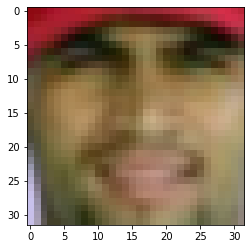

In [0]:
img_shape = (CHANNELS, IMG_SIZE, IMG_SIZE)

cuda = True if torch.cuda.is_available() else False 

os.makedirs(outputdir, exist_ok=True)

randomseed = random.randint(1, 10000)
random.seed(randomseed)
torch.manual_seed(randomseed)

# preprocessing for mnist, lsun, cifar10
if dataset_name == 'mnist': 
	dataset = datasets.MNIST(root = dataroot, train=True,download=True, 
		transform=transforms.Compose([transforms.Resize(IMG_SIZE), 
			transforms.ToTensor(), 
			transforms.Normalize((0.5,), (0.5,))]))

elif dataset_name == 'lsun': 
	dataset = datasets.LSUN(root = dataroot, train=True,download=True, 
		transform=transforms.Compose([transforms.Resize(IMG_SIZE), 
			transforms.CenterCrop(IMG_SIZE),
			transforms.ToTensor(), 
			transforms.Normalize((0.5,), (0.5,))]))

elif dataset_name == 'cifar10':  
	dataset = datasets.CIFAR10(root = dataroot, train=True,download=True, 
		transform=transforms.Compose([transforms.Resize(IMG_SIZE), 
			transforms.ToTensor(), 
			transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))
 
elif dataset_name == 'celeb': 
	dataset = datasets.CelebA(root = dataroot, split='train',download=False, target_type='attr', 
		transform=transforms.Compose([
			#transforms.Resize((IMG_SIZE*2, IMG_SIZE)), 
		  transforms.CenterCrop(IMG_SIZE*3),
			transforms.Resize((IMG_SIZE, IMG_SIZE)), 
			transforms.ToTensor(), 
			transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))

elif dataset_name == 'lfwcrop': 
	dataset = LFWCrop(lfwroot, transform=transforms.Compose([
			# transforms.Resize((IMG_SIZE*2, IMG_SIZE)), 
			transforms.Resize((IMG_SIZE, IMG_SIZE)), 
			transforms.ToTensor()
			# transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
	 ]))

assert dataset
X, labels = dataset.__getitem__(200)
print("labels are of type" + str(type(labels)))
plt.imshow(X.permute(1, 2, 0))
print("Attribute list for shown image", labels)
print("Number of images", len(dataset))

# il train contiene 162.000 immagini circa. Ne analizziamo n_sample scelte randomicamente
n_sample = dataset.__len__()
train_indices = (np.random.randint(0, len(dataset), n_sample))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(train_indices)) # senza il sampler mettere shuffle=True

# Parameter Inizialization

In [0]:
# weight initialization
def init_weights(m): 
	if type(m)==nn.Linear:
		torch.nn.init.xavier_uniform_(m.weight)
		m.bias.data.fill_(0.01)

In [0]:
# Building Generator 
generator = Generator()
# gen_optimizer = torch.optim.Adam(generator.parameters(), lr=lrate, betas=(beta, beta1))
gen_optimizer = optim.SGD(generator.parameters(), lr=LR, momentum=0.9, weight_decay=5e-5)
# generator.load_state_dict(torch.load("%sgenerator.pth" % PATH_g))

# Building Discriminator  
discriminator = Discriminator()
# discriminator.load_state_dict(torch.load("%sdiscriminator.pth" % PATH_d))
discriminator.apply(init_weights)
# d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lrate, betas=(beta, beta1))
d_optimizer = optim.SGD(discriminator.parameters(), lr=LR, momentum=0.7, weight_decay=5e-5)

a_loss = torch.nn.BCELoss() # Loss functions 

# Labels 
real_label = 0.9
fake_label = 0.0

FT = torch.LongTensor
FT_a = torch.FloatTensor

if cuda: 
	generator.cuda()
	discriminator.cuda()
	a_loss.cuda()
	FT = torch.cuda.LongTensor
	FT_a = torch.cuda.FloatTensor


# **Training**

In [0]:
 fixed_noise = Variable(FT_a(np.random.normal(0, 1, (64, LAT_DIM))))
 imgs, labels = next(iter(dataloader))
 fixed_labels = Variable(labels[0:64].type(FT_a))

 for epoch in range(EPOCHS): 
	for i, (imgs, labels) in enumerate(dataloader): 
		batch_size = imgs.shape[0]
		
		# convert img, labels into proper form 
		imgs = Variable(imgs.type(FT_a))
		labels = Variable(labels.type(FT_a))
	
		# creating real and fake tensors of labels 
		reall = Variable(FT_a(batch_size, 1).fill_(real_label)) 		# label delle immagini reali per il discriminatore
		f_label = Variable(FT_a(batch_size, 1).fill_(fake_label)) 	# label delle immagini fake per il discriminatore

		# initializing gradient
		gen_optimizer.zero_grad() 
		d_optimizer.zero_grad()

		#### TRAINING DISCRIMINATOR ####
		noise = Variable(FT_a(np.random.normal(0, 1, (batch_size, LAT_DIM)))) # noise ha dimensione imgs.shape[0]xlatentdim imgs dovrebbero essere 64 foto (dimensione di un batch) x 100 pixel ogni foto?
		## Prima generiamo le immagini false tramite il generatore

		gen_labels = Variable(FT(np.random.randint(0, N_CLASSES, batch_size))) # sceglie dei numeri a caso da generare per le 64 immagini
		if dataset_name == 'lfwcrop':
			 gen_labels = labels
		gen_imgs = generator(noise, gen_labels, batch_size) # chiama il generatore passandogli il noise e le labels delle immagini che si aspetta vengano generati

		## Facciamo il training con le sole immagini vere e poi facciamo backward
		d_optimizer.zero_grad()

		# Loss for real images and labels 
		validity_real = discriminator(imgs, labels, batch_size) 	# fai il training usando le immagini vere
		d_real_loss = a_loss(validity_real, reall) 		# quante immagini vere sono state riconosciute come tali?

		d_real_loss.backward()
	
		## Facciamo il training con le sole immagini false e facciamo backward
		# Loss for fake images and labels 
		validity_fake = discriminator(gen_imgs.detach(), gen_labels, batch_size) # quante immagini false ha riconosciuto?
		d_fake_loss = a_loss(validity_fake, f_label)
	
		d_fake_loss.backward()

		# Total discriminator loss 
		d_loss = (d_fake_loss + d_real_loss) # fai una media dell'errore su vere e su false e usa questo nel backward

		# calculates discriminator gradients
		#d_loss.backward()
		d_optimizer.step()
			
		#### TRAINING GENERATOR ####
		# Ability for discriminator to discern the real v generated images 
		validity = discriminator(gen_imgs, gen_labels, batch_size)   # fai il train del discriminator sulle immagini false
		
		# Generative loss function 
		g_loss = a_loss(validity, reall)  # loss in base a quante immagini il discriminatore ha visto come reali (validity) 

		# Gradients 
		g_loss.backward()
		gen_optimizer.step()

	if (epoch + 1) % 10 == 0: 
		fake = generator(fixed_noise, fixed_labels, 64)
		vutils.save_image(fake.detach(), '%sfake_samples_epoch_%03d.png' % (outputdir, epoch+1), normalize=True)
	
	print("[Epoch: %d/%d]" "[D loss: %f]" "[G loss: %f]" % (epoch+1, EPOCHS, d_loss.item(), g_loss.item()))
	
	# checkpoints 
	torch.save(generator.state_dict(), '%s/generator.pth' % (outputdir))
	torch.save(discriminator.state_dict(), '%s/discriminator.pth' % (outputdir))


[Epoch: 1/2000][D loss: 0.475233][G loss: 4.285619]
[Epoch: 2/2000][D loss: 0.468593][G loss: 4.081654]
[Epoch: 3/2000][D loss: 0.538835][G loss: 4.180163]
[Epoch: 4/2000][D loss: 0.456387][G loss: 5.075933]
[Epoch: 5/2000][D loss: 1.876297][G loss: 2.081367]
[Epoch: 6/2000][D loss: 1.286486][G loss: 1.898317]
[Epoch: 7/2000][D loss: 0.888868][G loss: 1.712614]
[Epoch: 8/2000][D loss: 0.604781][G loss: 2.684053]
[Epoch: 9/2000][D loss: 0.521427][G loss: 2.675998]
[Epoch: 10/2000][D loss: 0.644774][G loss: 2.585333]
[Epoch: 11/2000][D loss: 0.507357][G loss: 3.422472]
[Epoch: 12/2000][D loss: 0.433466][G loss: 3.796253]
[Epoch: 13/2000][D loss: 0.429723][G loss: 5.408910]
[Epoch: 14/2000][D loss: 0.457914][G loss: 4.990247]
[Epoch: 15/2000][D loss: 1.485328][G loss: 2.636921]
[Epoch: 16/2000][D loss: 0.513415][G loss: 4.830061]
[Epoch: 17/2000][D loss: 1.114954][G loss: 2.686399]
[Epoch: 18/2000][D loss: 0.587645][G loss: 4.596108]
[Epoch: 19/2000][D loss: 0.437660][G loss: 4.288182]
[E

# **Results**

In [0]:
X, gen_labels = dataset.__getitem__(2000)
gen_labels = Variable(gen_labels.type(FT_a))
noise = Variable(FT_a(np.random.normal(0, 1, (LAT_DIM, ))))
gen_imgs = X
gen_imgs = Variable(gen_imgs.type(FT_a))
gen_imgs = gen_imgs.view(1, 3, 32, 32)
print(gen_imgs.shape)


for i in range(1,10):
    gen_labels[3] = -6 + i*1.2
    # gen_labels[10] = -5 + i*1
    # gen_labels[6] = -2 - i*0.4
    # gen_labels[7] = 2 - i*0.4
    # gen_labels[8] = 3 - i*0.6

    print(gen_labels)
    img = generator(noise, gen_labels, 1)
    print(img.shape)
    gen_imgs = torch.cat((gen_imgs, img), -1)
    vutils.save_image(gen_imgs, 'final_gen_sample_%d.png' % i)


plt.imshow(X.permute(1, 2, 0))
plt.imshow(gen_imgs.cpu().detach()[0].permute(1,2,0))

In [0]:
generator.load_state_dict(torch.load(PATH_g))
generator.eval()

discriminator.load_state_dict(torch.load(PATH_d))
discriminator.eval()

gen_labels = Variable(FT_a(2*np.random.standard_normal(size=(BATCH_SIZE, N_CLASSES))))
noise = Variable(FT_a(np.random.normal(0, 1, (BATCH_SIZE, LAT_DIM))))

gen_imgs = generator(noise, gen_labels, BATCH_SIZE)
vutils.save_image(gen_imgs, '%s/final_gen_sample.png' % outputdir)